In [25]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_curve, auc, matthews_corrcoef

In [6]:

uploaded = files.upload()

Saving dataset-features-categories.csv to dataset-features-categories (1).csv
Saving drebin-215-dataset-5560malware-9476-benign.csv to drebin-215-dataset-5560malware-9476-benign (1).csv


In [7]:
df1 = pd.read_csv("dataset-features-categories.csv")
df2 = pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv")

<ipython-input-7-d06ce08c1713>:2: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv")


In [8]:
print("missing values : ",sum(list(df1.isna().sum())))
df1

missing values :  0


,transact,API call signature
0,onServiceConnected,API call signature
1,bindService,API call signature
2,attachInterface,API call signature
3,ServiceConnection,API call signature
4,android.os.Binder,API call signature
...,...,...
210,ACCESS_FINE_LOCATION,Manifest Permission
211,SET_WALLPAPER_HINTS,Manifest Permission
212,SET_PREFERRED_APPLICATIONS,Manifest Permission
213,WRITE_SECURE_SETTINGS,Manifest Permission


**Missing values**
Visual inspection show that missing values are "?". Having a lot of variables means that dropping programs with ? values delete the dataset entirely. Therefore, I went for assuming that if the value is missing, that program doesn't request that permission, as it makes more sense than Most Frequent, and way simpler and computationally effective than using MICE or creating a new category (0.5)

In [9]:
print(df2["class"].unique())

['S' 'B']


I'll also have to transform in numeric the target class. 0 = B and 1 = S (Malaware)

In [10]:
# Missing Values

df2 = df2.replace('?', np.nan)
cols_to_numeric = df2.columns.drop("class")
df2[cols_to_numeric] = df2[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

# impute missing with 0, the suspicious behavior is assumed to be lacking, as the lack of a permit request is never suspicious behavior
df2.fillna(0, inplace=True)

# convert class column
df2["class"] = df2["class"].str.upper()
df2 = df2[df2["class"].isin(["B", "S"])]
df2["class"] = df2["class"].map({"B": 0, "S": 1}).astype(int)

**Split**
15% test 15% evaluation 70%train

In [11]:
#Train Test Split
x = df2.drop("class", axis=1)
y = df2["class"]
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

**Checking for unbalanced class and solving**

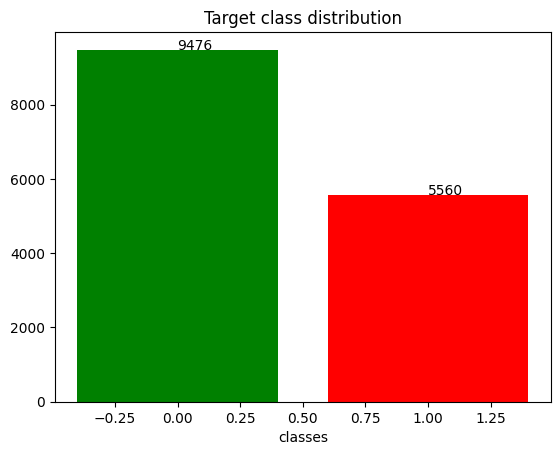

In [12]:
#are class balanced?
classes,count = np.unique(df2['class'],return_counts=True)
plt.bar(classes, count, color=['Green', 'Red'])
for i in range(len(classes)):
    plt.text(classes[i], count[i] + 1, str(count[i]))

plt.title("Target class distribution")
plt.xlabel("classes")
plt.show()

In [13]:
#IR
imbalance_ratio = count[0] / count[1]
print(f"Imbalance Ratio (IR): {imbalance_ratio:.2f}")

Imbalance Ratio (IR): 1.70


I.R. bigger than 1.50 usually means that the class is unbalanced. I'll use Oversampling to adress this, but more could be experimented (class weights is something i usually like more, maybe I'll try later)

In [14]:
#Important to oversample only the training set
ros = RandomOverSampler(random_state=42)
x_train, y_train = ros.fit_resample(x_train, y_train)

**Feature Engineering**

chi square is donde to check for independence. It require non-negative values (we have binary so perfect) and is done on the train test alone to not use informations from the test/evaluation set

In [15]:
#chi square test for checking independence
chi2_scores, p_values = chi2(x_train, y_train)
alpha = 0.05  # significance level, other values might be tried. with 0.5 only 10 features are independent

# Keep features that are not independent with target
significant_mask = p_values < alpha
x_train_filtered = x_train.loc[:, significant_mask]
x_val_filtered = x_val.loc[:, significant_mask]
x_test_filtered = x_test.loc[:, significant_mask]

kept_features = x_train.columns[significant_mask]
print(f"Kept {len(kept_features)} features based on Chi² at α = {alpha}")

Kept 203 features based on Chi² at α = 0.05


first model: **Support Vector Machine**


--- Kernel: linear ---


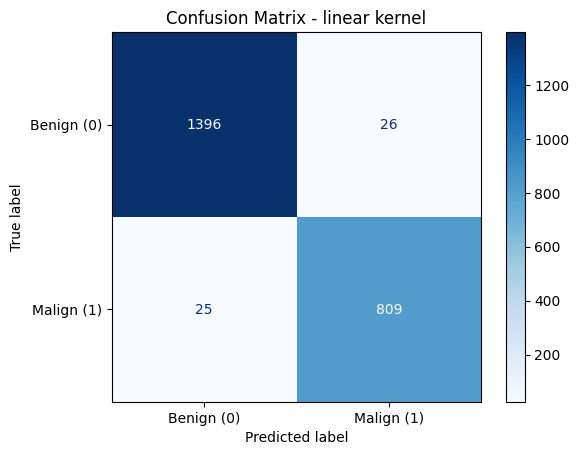

Matthews Correlation Coefficient (MCC): 0.9515

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      1422
      Malign       0.97      0.97      0.97       834

    accuracy                           0.98      2256
   macro avg       0.98      0.98      0.98      2256
weighted avg       0.98      0.98      0.98      2256


--- Kernel: poly ---


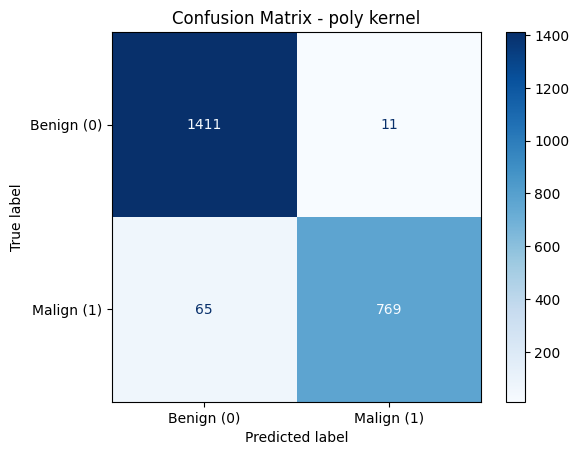

Matthews Correlation Coefficient (MCC): 0.9280

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97      1422
      Malign       0.99      0.92      0.95       834

    accuracy                           0.97      2256
   macro avg       0.97      0.96      0.96      2256
weighted avg       0.97      0.97      0.97      2256


--- Kernel: rbf ---


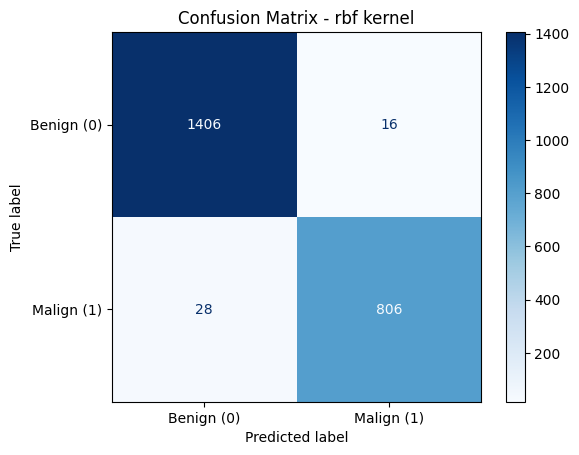

Matthews Correlation Coefficient (MCC): 0.9581

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98      1422
      Malign       0.98      0.97      0.97       834

    accuracy                           0.98      2256
   macro avg       0.98      0.98      0.98      2256
weighted avg       0.98      0.98      0.98      2256



In [28]:
#SVM
kernels = ['linear', 'poly', 'rbf'] #i'll try three different popular kernels

for k in kernels:
    print(f"\n--- Kernel: {k} ---")

    model = SVC(kernel=k)
    model.fit(x_train_filtered, y_train)
    #predictions
    y_pred = model.predict(x_test_filtered)
    # confusion catrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malign (1)"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {k} kernel")
    plt.show()
    # MCC (some people say its best to evaluate confusion matrixes). Im open to use other metrics as imo false positives are better than false negative as cost of wrong classification is different but i'm short on ideas on the how.
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
    # Precision, Recall, F1
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Benign", "Malign"]))

second model: **Random Forest Classifier**

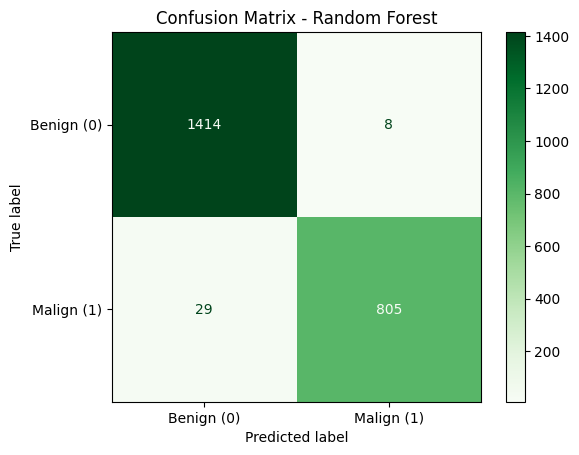

Matthews Correlation Coefficient (MCC): 0.9648

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99      1422
      Malign       0.99      0.97      0.98       834

    accuracy                           0.98      2256
   macro avg       0.99      0.98      0.98      2256
weighted avg       0.98      0.98      0.98      2256



In [26]:
#Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train_filtered, y_train)
#predictions
y_pred = rf.predict(x_test_filtered)

# confusion catrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malign (1)"])
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Random Forest")
plt.show()
# MCC (some people say its best to evaluate confusion matrixes). Im open to use other metrics as imo false positives are better than false negative as cost of wrong classification is different but i'm short on ideas on the how.
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
# Precision, Recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malign"]))

# Compute ROC curve and AUC (nope)
#y_prob = rf.predict_proba(x_test_filtered)[:, 1]
#fpr, tpr, _ = roc_curve(y_test, y_prob)
#roc_auc = auc(fpr, tpr)
# Plot
#plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
#plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
#plt.xlabel("False Positive Rate")
#plt.ylabel("True Positive Rate")
#plt.title("ROC Curve")
#plt.legend()
#plt.grid(True)
#plt.show()


Third model: ***Logistic Regression***

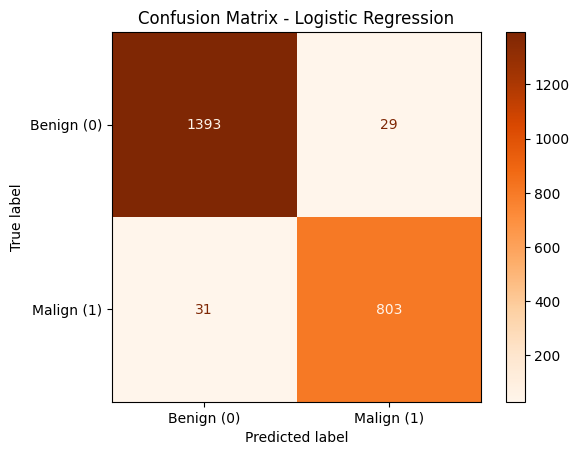

Matthews Correlation Coefficient (MCC): 0.9429

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98      1422
      Malign       0.97      0.96      0.96       834

    accuracy                           0.97      2256
   macro avg       0.97      0.97      0.97      2256
weighted avg       0.97      0.97      0.97      2256



In [27]:
# Logistic Regression
logreg = LogisticRegression(random_state=42, max_iter=1000)  # max_iter bigger than default to ensure convergence
logreg.fit(x_train_filtered, y_train)
#predictions
y_pred = logreg.predict(x_test_filtered)

# confusion catrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malign (1)"])
disp.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
# MCC (some people say its best to evaluate confusion matrixes). Im open to use other metrics as imo false positives are better than false negative as cost of wrong classification is different but i'm short on ideas on the how.
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
# Precision, Recall, F1
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malign"]))


**Bypassing the model**
First, flippig some 0 in 1 for the removed features should yeald close to no result aside confusion, so removing those probably makes the model more resistant.
My apporach would be to pick features that have 0 for the sample ordered by importance and turn to 1 to diluite/confuse the model.

In [30]:
malware_sample = x_test_filtered[y_test == 1].iloc[0].copy()
original_sample = malware_sample.copy()  # to compare
print("Original prediction:", rf.predict([malware_sample])[0])

#i'll use random forest which behaved better than the other methods
importances = rf.feature_importances_
feature_names = x_test_filtered.columns

# rank by importance features that are 0 for the sample
zero_features = malware_sample[malware_sample == 0].index.tolist()
low_importance_features = sorted(zero_features, key=lambda f: importances[list(feature_names).index(f)])

# try flip from lower to most until success
for f in low_importance_features:
    malware_sample[f] = 1
    pred = rf.predict([malware_sample])[0]
    if pred == 0:
        print(f"Success! Model fooled by flipping feature: {f}")
        break

#output
num_flipped = (malware_sample != original_sample).sum()
print(f"Total features flipped: {num_flipped}")
print("\nFlipped from 0 into 1 features:")
flipped = malware_sample != original_sample
print(original_sample[flipped])
print("new prediction:", rf.predict([malware_sample])[0])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

Original prediction: 1


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

Success! Model fooled by flipping feature: RECEIVE_WAP_PUSH
Total features flipped: 88

Flipped from 0 into 1 features:
NFC                                             0.0
URLClassLoader                                  0.0
BIND_REMOTEVIEWS                                0.0
getCallingPid                                   0.0
READ_SYNC_STATS                                 0.0
                                               ... 
android.intent.action.ACTION_POWER_CONNECTED    0.0
BIND_VPN_SERVICE                                0.0
ACCESS_MOCK_LOCATION                            0.0
SET_ORIENTATION                                 0.0
SET_WALLPAPER_HINTS                             0.0
Name: 1540, Length: 88, dtype: float64
new prediction: 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
